In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# Path to your event log CSV
log_path = "D:/Projects/Big\opra\data\logs\BPIC_2012\BPIC_2012_train.csv"

# Read log
df_log = pd.read_csv(log_path)

# Detect case id column
if "case_id" in df_log.columns:
    case_col = "case_id"
elif "case" in df_log.columns:
    case_col = "case"

else:
    raise ValueError("No case id column found. Expected 'caseid' or 'case'.")

# Group by case id (number of events per case)
cases_grouped = df_log.groupby(case_col).size().reset_index(name="num_events")

# Number of cases
num_cases = cases_grouped.shape[0]
print(f"Number of cases: {num_cases}")

# cases_grouped.head()

model_metrics_path = "D:/Projects/Big/opra/data/training_models/BPIC_2012_DDPS_p75_300_3000_tp90_tk2_pe30_a0_resource_only"

Number of cases: 3030


In [16]:
df_agents = pd.read_csv(f"{model_metrics_path}/update_metrics.csv")

df_agents.head()

,update,episode,policy_loss,value_loss,entropy,total_loss,approx_kl,clip_fraction
0,1,1,-0.013140,0.491120,3.663557,0.441344,NaN,NaN
1,2,2,0.027029,0.464155,3.664620,0.454538,NaN,NaN
2,3,3,0.051000,0.442906,3.662893,0.457276,NaN,NaN
3,4,4,0.061434,0.422733,3.663171,0.447535,NaN,NaN
4,5,5,0.121712,0.384848,3.661481,0.469946,NaN,NaN


In [17]:
df_episode = pd.read_csv(f"{model_metrics_path}/episode_metrics.csv")

df_episode.head()

,episode,total_reward,num_steps,num_cases,num_compliant,sla_compliance_rate,avg_cycle_time,median_cycle_time,std_cycle_time,min_cycle_time,max_cycle_time,p75_cycle_time,p90_cycle_time,p95_cycle_time,episode_duration_sec,resource_utilization_cv
0,1,492.312263,23689,3000,1910,0.636667,1.327248e+06,546612.808117,2.562201e+06,0.725,1.825230e+07,1.378436e+06,2.773201e+06,6.658586e+06,31.005354,NaN
1,2,526.375187,23960,3000,1934,0.644667,1.235227e+06,577891.359192,2.217201e+06,0.776,1.567994e+07,1.394083e+06,2.794538e+06,5.124178e+06,30.110654,NaN
2,3,590.797290,23733,3000,1940,0.646667,1.247750e+06,488752.147639,2.329449e+06,0.970,1.693104e+07,1.395077e+06,2.794223e+06,5.847040e+06,36.108638,NaN
3,4,495.709670,23871,3000,1908,0.636000,1.332483e+06,525655.533810,2.572837e+06,0.827,1.887428e+07,1.449022e+06,2.780522e+06,6.230547e+06,31.535167,NaN
4,5,554.329361,23551,3000,1912,0.637333,1.266812e+06,504996.508892,2.355292e+06,0.776,1.599985e+07,1.371727e+06,2.859856e+06,6.026770e+06,33.066220,NaN


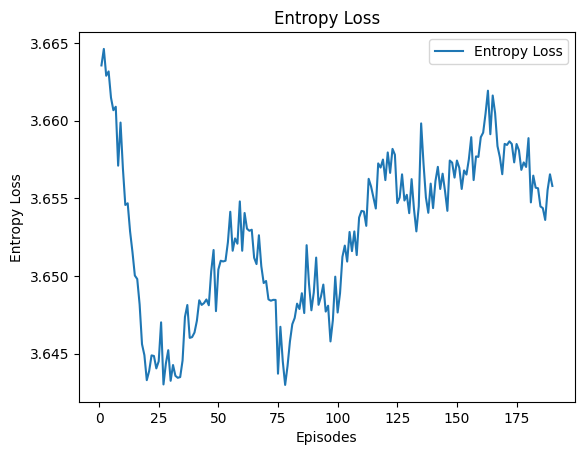

In [18]:
plt.plot(df_agents["episode"], df_agents['entropy'], label="Entropy Loss")
plt.xlabel("Episodes")
plt.ylabel("Entropy Loss")
plt.title("Entropy Loss")
plt.legend()
plt.show()

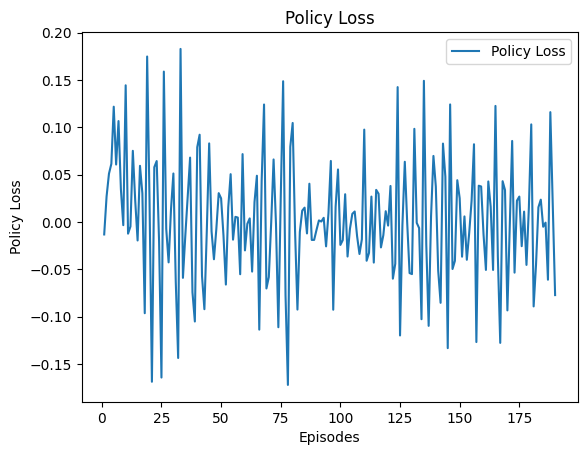

In [19]:
plt.plot(df_agents["episode"], df_agents['policy_loss'], label="Policy Loss")
plt.xlabel("Episodes")
plt.ylabel("Policy Loss")
plt.title("Policy Loss")
plt.legend()
plt.show()

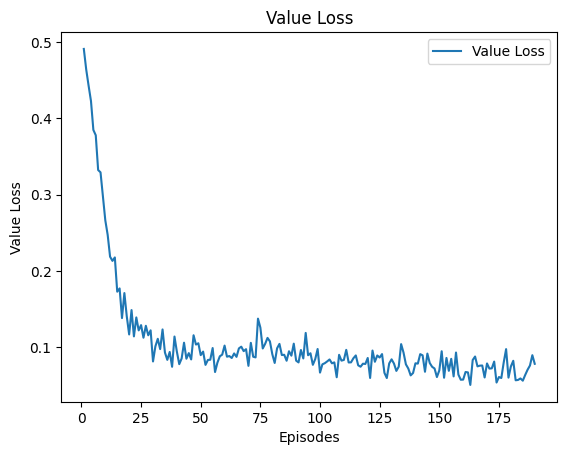

In [20]:
plt.plot(df_agents["episode"], df_agents['value_loss'], label="Value Loss")
plt.xlabel("Episodes")
plt.ylabel("Value Loss")
plt.title("Value Loss")
plt.legend()
plt.show()

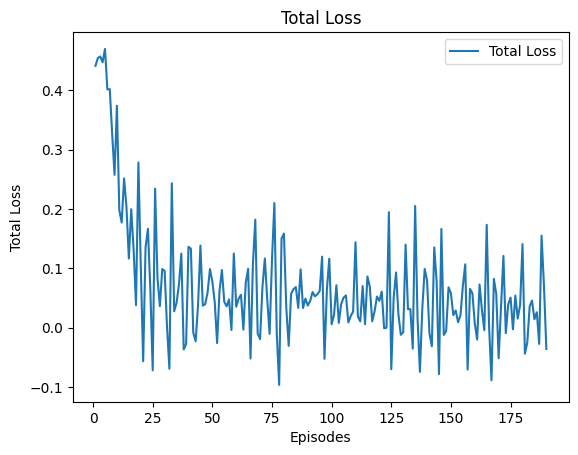

In [21]:
plt.plot(df_agents["episode"], df_agents['total_loss'], label="Total Loss")
plt.xlabel("Episodes")
plt.ylabel("Total Loss")
plt.title("Total Loss")
plt.legend()
plt.show()

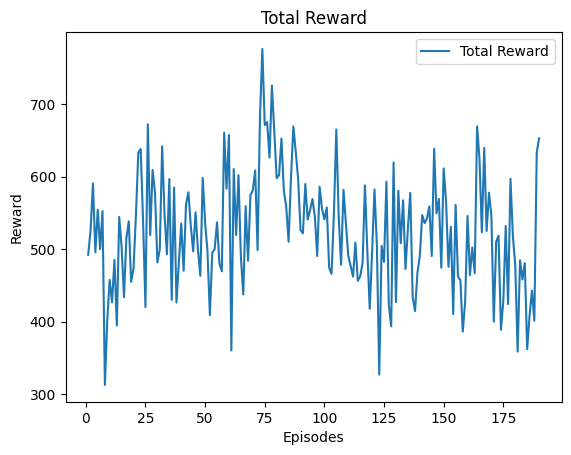

In [22]:
plt.plot(df_episode["episode"], df_episode['total_reward'], label="Total Reward")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Total Reward")
plt.legend()
plt.show()